In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import shap

In [2]:
print("=====================================================================")
print("🌐 NOTEBOOK 08B - CELL 1: SHAP DATA PIPELINE INGESTION")
print("=====================================================================")

# 1. Pipeline Verification Gate
model_file = "travel_risk_model.pkl"
schema_file = "model_feature_schema.pkl"
data_file = "master_feature_table_with_hazards.csv"

for file in [model_file, schema_file, data_file]:
    if not os.path.exists(file):
        raise FileNotFoundError(f"Missing required pipeline artifact: '{file}'. Please run Notebook 08A first.")

🌐 NOTEBOOK 08B - CELL 1: SHAP DATA PIPELINE INGESTION


In [3]:
# Load frozen pipeline assets
champion_model = joblib.load(model_file)
feature_columns = joblib.load(schema_file)
df = pd.read_csv(data_file)

# Reconstruct exact feature matrix space
X = df[feature_columns].astype(float)
print(f" -> Production Model Restored : {type(champion_model).__name__}")
print(f" -> Feature Space Realigned   : {X.shape[0]} historical rows x {X.shape[1]} inputs")

 -> Production Model Restored : XGBRegressor
 -> Feature Space Realigned   : 18260 historical rows x 19 inputs


In [4]:
# 2. Extract and Initialize Tree-Optimized SHAP Context
try:
    import shap
    print("\n🚀 SHAP library framework detected. Initializing TreeExplainer...")
    
    # Initialize explainer natively optimized for tree-based architectures
    explainer = shap.TreeExplainer(champion_model)
    
    # We sample 1,000 diverse rows to calculate global attribution metrics instantly without lag
    X_sample = X.sample(n=1000, random_state=42)
    shap_values = explainer(X_sample)
    
    print(" ✅ SUCCESS: SHAP Additive Attribution Matrix calculated over sampling block!")
    shap_ready = True
except ImportError:
    print("\n ❌ Environment Error: The 'shap' library is not installed in this kernel.")
    print(" -> Action Required: Please run '!pip install shap' in a cell or terminal first.")
    shap_ready = False
print("=====================================================================")


🚀 SHAP library framework detected. Initializing TreeExplainer...
 ✅ SUCCESS: SHAP Additive Attribution Matrix calculated over sampling block!


🎨 NOTEBOOK 08B - CELL 2: GLOBAL SHAP SUMMARY BEESWARM PLOT


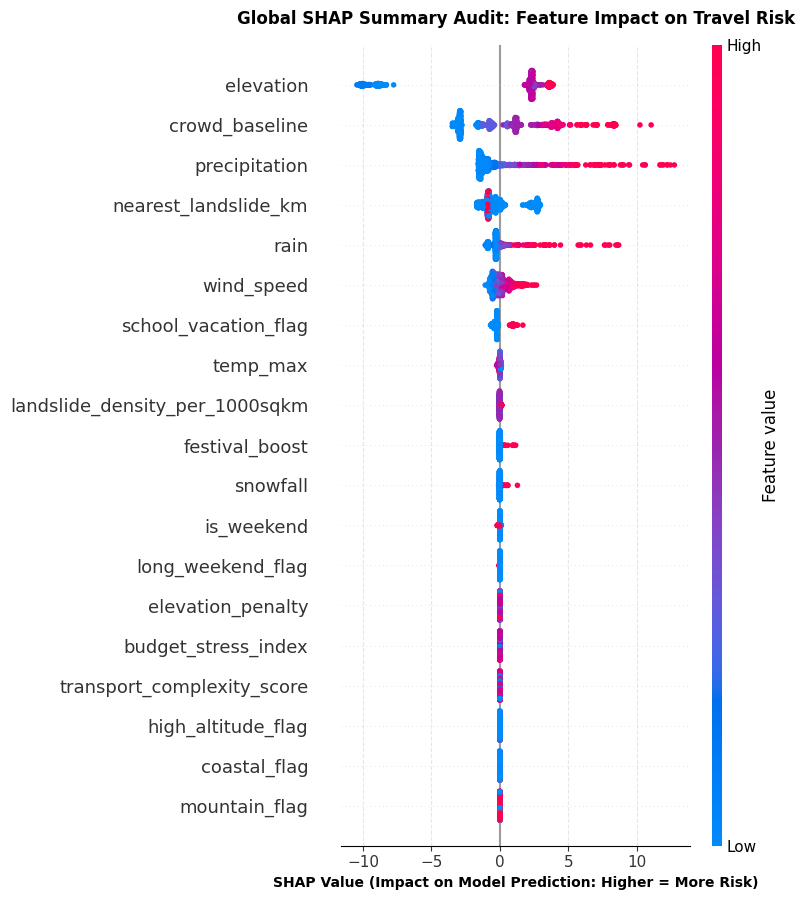


🎨 Success! Master SHAP Global Summary plot exported to disk as 'ml_shap_global_summary.png'


In [5]:
print("=====================================================================")
print("🎨 NOTEBOOK 08B - CELL 2: GLOBAL SHAP SUMMARY BEESWARM PLOT")
print("=====================================================================")

# 1. Render the standard global SHAP beeswarm summary plot cleanly
# We set show=False so we can manually adjust formatting and save the high-res file
shap.summary_plot(shap_values, X_sample, show=False)

# 2. Add professional formatting over the canvas layout
plt.title("Global SHAP Summary Audit: Feature Impact on Travel Risk", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("SHAP Value (Impact on Model Prediction: Higher = More Risk)", fontsize=10, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3, axis="x")

# 3. Export the high-resolution visualization asset straight to your workspace disk
output_shap_summary_png = "ml_shap_global_summary.png"
plt.tight_layout()
plt.savefig(output_shap_summary_png, dpi=300)
plt.show()
print(f"\n🎨 Success! Master SHAP Global Summary plot exported to disk as '{output_shap_summary_png}'")
print("=====================================================================")

In [6]:
print("=====================================================================")
print("🎨 NOTEBOOK 08B - CELL 3: SHAP DEPENDENCE INTERACTION PLOT")
print("=====================================================================")

🎨 NOTEBOOK 08B - CELL 3: SHAP DEPENDENCE INTERACTION PLOT


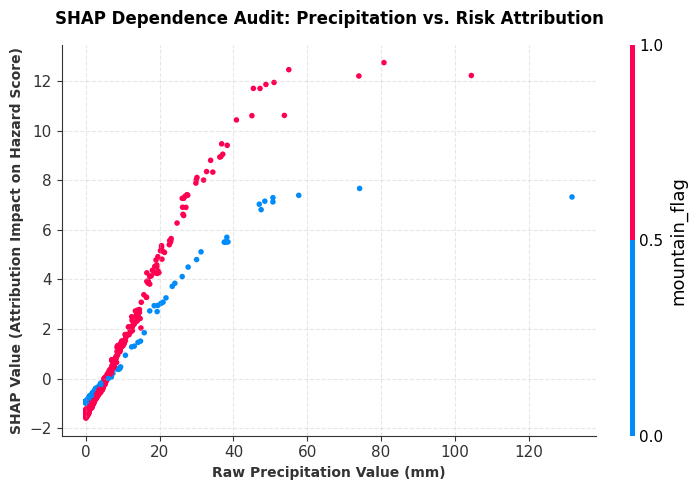


🎨 Success! SHAP Dependence Interaction plot exported to disk as 'ml_shap_dependence_precipitation.png'


In [9]:
# 1. Render the dependence plot focusing on precipitation
# SHAP automatically selects the strongest interacting feature to color the dots!
shap.dependence_plot("precipitation", shap_values.values, X_sample, show=False)

# 2. Apply professional formatting custom adjustments
plt.title("SHAP Dependence Audit: Precipitation vs. Risk Attribution", fontsize=12, fontweight="bold", pad=15)
plt.ylabel("SHAP Value (Attribution Impact on Hazard Score)", fontsize=10, fontweight="bold")
plt.xlabel("Raw Precipitation Value (mm)", fontsize=10, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.3)

# 3. Export the diagnostic graphic to disk
output_dependence_png = "ml_shap_dependence_precipitation.png"
plt.tight_layout()
plt.savefig(output_dependence_png, dpi=300)
plt.show()

print(f"\n🎨 Success! SHAP Dependence Interaction plot exported to disk as '{output_dependence_png}'")
print("=====================================================================")

🎨 NOTEBOOK 08B - CELL 4: LOCAL SHAP WATERFALL ATTRUBUTION PLOT


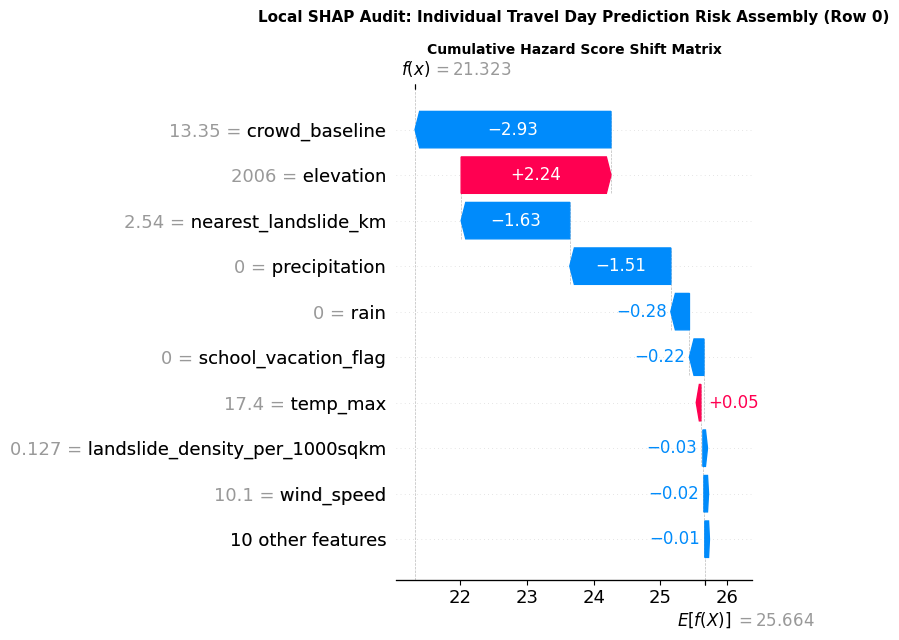


🎨 Success! Individual Local SHAP Waterfall chart exported to disk as 'ml_shap_local_waterfall.png'
🚀 NOTEBOOK 08B: EXPLAINABILITY AUDIT COMPLETED AND LOCKED DOWN!


In [10]:
print("=====================================================================")
print("🎨 NOTEBOOK 08B - CELL 4: LOCAL SHAP WATERFALL ATTRUBUTION PLOT")
print("=====================================================================")

# 1. Isolate one single observation from our sample space to audit locally
# We select row index 0 from our calculated sample matrix
target_row_index = 0

# 2. Render the clean local waterfall plot layout
shap.plots.waterfall(shap_values[target_row_index], show=False)

# 3. Apply custom corporate styling and polish
plt.title(f"Local SHAP Audit: Individual Travel Day Prediction Risk Assembly (Row {target_row_index})", fontsize=11, fontweight="bold", pad=15)
plt.xlabel("Cumulative Hazard Score Shift Matrix", fontsize=10, fontweight="bold")

# 4. Save and export the final explainability asset
output_waterfall_png = "ml_shap_local_waterfall.png"
plt.tight_layout()
plt.savefig(output_waterfall_png, dpi=300)
plt.show()

print(f"\n🎨 Success! Individual Local SHAP Waterfall chart exported to disk as '{output_waterfall_png}'")
print("=====================================================================")
print("🚀 NOTEBOOK 08B: EXPLAINABILITY AUDIT COMPLETED AND LOCKED DOWN!")
print("=====================================================================")

In [11]:
print("=====================================================================")
print("🏆 NOTEBOOK 08B COMPLIMENTARY ASSURANCES: SHAP IMPORTANCE EXTRACTOR")
print("=====================================================================")

# 1. Calculate Mean Absolute SHAP values across the entire sampled row space
shap_importance = pd.DataFrame({
    "Feature Space Attribute": X_sample.columns,
    "Mean Absolute SHAP (Magnitude Impact)": np.abs(shap_values.values).mean(axis=0)
})

# 2. Sort systematically to establish the definitive machine-learned hierarchy
shap_importance = shap_importance.sort_values(
    by="Mean Absolute SHAP (Magnitude Impact)",
    ascending=False
).reset_index(drop=True)

print(shap_importance.to_string(index=False))

# 3. Export to disk as a concrete portfolio verification report
output_shap_csv = "shap_global_importance_ranking.csv"
shap_importance.to_csv(output_shap_csv, index=False)

print("\n=====================================================================")
print(f" ✅ SUCCESS: Defensible SHAP ranking matrix exported to: '{output_shap_csv}'")
print("=====================================================================")
print("🚀 EXPERIMENTAL FRAMEWORK CONFIRMED. READY FOR PRODUCTION API SERVER.")
print("=====================================================================")

🏆 NOTEBOOK 08B COMPLIMENTARY ASSURANCES: SHAP IMPORTANCE EXTRACTOR
       Feature Space Attribute  Mean Absolute SHAP (Magnitude Impact)
                     elevation                               3.992640
                crowd_baseline                               2.690761
                 precipitation                               1.616878
          nearest_landslide_km                               1.104882
                          rain                               0.514184
                    wind_speed                               0.456844
          school_vacation_flag                               0.402368
                      temp_max                               0.040271
landslide_density_per_1000sqkm                               0.038084
                festival_boost                               0.023384
                      snowfall                               0.019825
                    is_weekend                               0.014216
             long_weeke